In [1]:
#Importamos las librerias pandas, numpy y matplotlib respectivamente
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
#Carga desde un archivo .csv sin indice
data = pd.read_csv('listings_Paris.csv')
data.head(5)

,id,listing_url,scrape_id,last_scraped,source,name,description,neighborhood_overview,picture_url,host_id,...,review_scores_communication,review_scores_location,review_scores_value,license,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month
0,3109,https://www.airbnb.com/rooms/3109,20240906025355,2024-09-11,city scrape,zen and calm,Lovely Appartment with one bedroom with a Quee...,Good restaurants<br />very close the Montparna...,https://a0.muscache.com/pictures/miso/Hosting-...,3631,...,5.00,5.00,5.00,7511409139079,t,1,1,0,0,0.05
1,5396,https://www.airbnb.com/rooms/5396,20240906025355,2024-09-13,city scrape,Your perfect Paris studio on Île Saint-Louis,"NEW SOFA-BED SINCE JUNE 2023, Please disregard...","You are within walking distance to the Louvre,...",https://a0.muscache.com/pictures/52413/f9bf76f...,7903,...,4.84,4.96,4.59,7510402838018,f,1,1,0,0,2.23
2,7397,https://www.airbnb.com/rooms/7397,20240906025355,2024-09-06,city scrape,MARAIS - 2ROOMS APT - 2/4 PEOPLE,"VERY CONVENIENT, WITH THE BEST LOCATION !",NaN,https://a0.muscache.com/pictures/67928287/330b...,2626,...,4.89,4.93,4.74,7510400829623,f,1,1,0,0,2.20
3,7964,https://www.airbnb.com/rooms/7964,20240906025355,2024-09-10,previous scrape,Sunny apartment with balcony,"We are renting our a spacious, sunny fully fur...",NaN,https://a0.muscache.com/pictures/miso/Hosting-...,22155,...,5.00,5.00,5.00,7510903576564,f,1,1,0,0,0.03
4,241715,https://www.airbnb.com/rooms/241715,20240906025355,2024-09-11,city scrape,Big Cosy Appartement with 100 m2 Terrace in Paris,Come to stay in our unique Parisian flat to en...,"The 19th arrondissement of Paris, located in t...",https://a0.muscache.com/pictures/miso/Hosting-...,3342097,...,NaN,NaN,NaN,7511913070313,f,1,1,0,0,NaN


In [3]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 95461 entries, 0 to 95460
Data columns (total 75 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   id                                            95461 non-null  int64  
 1   listing_url                                   95461 non-null  object 
 2   scrape_id                                     95461 non-null  int64  
 3   last_scraped                                  95461 non-null  object 
 4   source                                        95461 non-null  object 
 5   name                                          95461 non-null  object 
 6   description                                   91385 non-null  object 
 7   neighborhood_overview                         48179 non-null  object 
 8   picture_url                                   95459 non-null  object 
 9   host_id                                       95461 non-null 

In [4]:
df = pd.DataFrame(data)

# Eliminar el símbolo de dólar y las comas, luego convertir a float
df['price'] = df['price'].replace({'\$': '', ',': ''}, regex=True).astype(float)

# Mostrar los resultados
print(df)

<>:4: SyntaxWarning: invalid escape sequence '\$'
<>:4: SyntaxWarning: invalid escape sequence '\$'
C:\Users\sarah\AppData\Local\Temp\ipykernel_5556\701884519.py:4: SyntaxWarning: invalid escape sequence '\$'
  df['price'] = df['price'].replace({'\$': '', ',': ''}, regex=True).astype(float)


                        id                                       listing_url  \
0                     3109                 https://www.airbnb.com/rooms/3109   
1                     5396                 https://www.airbnb.com/rooms/5396   
2                     7397                 https://www.airbnb.com/rooms/7397   
3                     7964                 https://www.airbnb.com/rooms/7964   
4                   241715               https://www.airbnb.com/rooms/241715   
...                    ...                                               ...   
95456  1238568635341928457  https://www.airbnb.com/rooms/1238568635341928457   
95457  1238594326004996232  https://www.airbnb.com/rooms/1238594326004996232   
95458  1238755949783144791  https://www.airbnb.com/rooms/1238755949783144791   
95459  1239120896239244086  https://www.airbnb.com/rooms/1239120896239244086   
95460  1239136641042729451  https://www.airbnb.com/rooms/1239136641042729451   

            scrape_id last_scraped     

In [42]:
#Eliminar columnas innecesarias
#axis = 1 para columnas
#axis = 0 para filas
data1= df.drop(['neighbourhood_group_cleansed', 'calendar_updated', 'calculated_host_listings_count_private_rooms', 'calculated_host_listings_count_shared_rooms'], axis=1)
data1

,id,listing_url,scrape_id,last_scraped,source,name,description,neighborhood_overview,picture_url,host_id,...,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,license,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,reviews_per_month
0,3109,https://www.airbnb.com/rooms/3109,20240906025355,2024-09-11,city scrape,zen and calm,Lovely Appartment with one bedroom with a Quee...,Good restaurants<br />very close the Montparna...,https://a0.muscache.com/pictures/miso/Hosting-...,3631,...,5.00,5.00,5.00,5.00,5.00,7511409139079,t,1,1,0.05
1,5396,https://www.airbnb.com/rooms/5396,20240906025355,2024-09-13,city scrape,Your perfect Paris studio on Île Saint-Louis,"NEW SOFA-BED SINCE JUNE 2023, Please disregard...","You are within walking distance to the Louvre,...",https://a0.muscache.com/pictures/52413/f9bf76f...,7903,...,4.59,4.81,4.84,4.96,4.59,7510402838018,f,1,1,2.23
2,7397,https://www.airbnb.com/rooms/7397,20240906025355,2024-09-06,city scrape,MARAIS - 2ROOMS APT - 2/4 PEOPLE,"VERY CONVENIENT, WITH THE BEST LOCATION !",NaN,https://a0.muscache.com/pictures/67928287/330b...,2626,...,4.45,4.92,4.89,4.93,4.74,7510400829623,f,1,1,2.20
3,7964,https://www.airbnb.com/rooms/7964,20240906025355,2024-09-10,previous scrape,Sunny apartment with balcony,"We are renting our a spacious, sunny fully fur...",NaN,https://a0.muscache.com/pictures/miso/Hosting-...,22155,...,5.00,5.00,5.00,5.00,5.00,7510903576564,f,1,1,0.03
4,241715,https://www.airbnb.com/rooms/241715,20240906025355,2024-09-11,city scrape,Big Cosy Appartement with 100 m2 Terrace in Paris,Come to stay in our unique Parisian flat to en...,"The 19th arrondissement of Paris, located in t...",https://a0.muscache.com/pictures/miso/Hosting-...,3342097,...,NaN,NaN,NaN,NaN,NaN,7511913070313,f,1,1,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95456,1238568635341928457,https://www.airbnb.com/rooms/1238568635341928457,20240906025355,2024-09-13,city scrape,"Spacieux studio 4P, porte st cloud",Forget your worries at this spacious (42m2) an...,NaN,https://a0.muscache.com/pictures/hosting/Hosti...,539077658,...,5.00,5.00,5.00,5.00,5.00,7550886324790,t,2,2,1.00
95457,1238594326004996232,https://www.airbnb.com/rooms/1238594326004996232,20240906025355,2024-09-11,city scrape,Luxury 3BR Arc Triomphe Champs Élysée,Spacious 3 Bedroom Apartment - Close to Champs...,NaN,https://a0.muscache.com/pictures/hosting/Hosti...,492686946,...,NaN,NaN,NaN,NaN,NaN,7516849364913,t,7,7,NaN
95458,1238755949783144791,https://www.airbnb.com/rooms/1238755949783144791,20240906025355,2024-09-07,city scrape,[F-16] 파리 5인여성 다인실방,Centrally located with the best accessibility.,NaN,https://a0.muscache.com/pictures/miso/Hosting-...,264290202,...,NaN,NaN,NaN,NaN,NaN,NaN,f,10,0,NaN
95459,1239120896239244086,https://www.airbnb.com/rooms/1239120896239244086,20240906025355,2024-09-13,city scrape,Large and bright flat nearby Montmartre - Paris,MIDTERM STAY ONLY - Located close to the mythi...,"Located 10 min away on foot from Montmartre, y...",https://a0.muscache.com/pictures/prohost-api/H...,169497320,...,NaN,NaN,NaN,NaN,NaN,"Available with a mobility lease only (""bail mo...",f,16,16,NaN


In [43]:
data1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 95461 entries, 0 to 95460
Data columns (total 71 columns):
 #   Column                                       Non-Null Count  Dtype  
---  ------                                       --------------  -----  
 0   id                                           95461 non-null  int64  
 1   listing_url                                  95461 non-null  object 
 2   scrape_id                                    95461 non-null  int64  
 3   last_scraped                                 95461 non-null  object 
 4   source                                       95461 non-null  object 
 5   name                                         95461 non-null  object 
 6   description                                  91385 non-null  object 
 7   neighborhood_overview                        48179 non-null  object 
 8   picture_url                                  95459 non-null  object 
 9   host_id                                      95461 non-null  int64  
 10

In [44]:
cualitativas=data1.iloc[ : , [1,3,4,5,6,7,8,10,11,12,13,14,15,16,17,18,19,20,21,24,25,26,27,28,31,32,35,38,48,53,57,58,66,67]]
cualitativas

,listing_url,last_scraped,source,name,description,neighborhood_overview,picture_url,host_url,host_name,host_since,...,property_type,room_type,bathrooms_text,amenities,has_availability,calendar_last_scraped,first_review,last_review,license,instant_bookable
0,https://www.airbnb.com/rooms/3109,2024-09-11,city scrape,zen and calm,Lovely Appartment with one bedroom with a Quee...,Good restaurants<br />very close the Montparna...,https://a0.muscache.com/pictures/miso/Hosting-...,https://www.airbnb.com/users/show/3631,Anne,2008-10-14,...,Entire rental unit,Entire home/apt,1 bath,"[""Cooking basics"", ""Luggage dropoff allowed"", ...",t,2024-09-11,2017-10-28,2019-10-24,7511409139079,t
1,https://www.airbnb.com/rooms/5396,2024-09-13,city scrape,Your perfect Paris studio on Île Saint-Louis,"NEW SOFA-BED SINCE JUNE 2023, Please disregard...","You are within walking distance to the Louvre,...",https://a0.muscache.com/pictures/52413/f9bf76f...,https://www.airbnb.com/users/show/7903,Borzou,2009-02-14,...,Entire rental unit,Entire home/apt,1 bath,"[""Hot water"", ""Stove"", ""Fire extinguisher"", ""O...",t,2024-09-13,2009-06-30,2024-09-01,7510402838018,f
2,https://www.airbnb.com/rooms/7397,2024-09-06,city scrape,MARAIS - 2ROOMS APT - 2/4 PEOPLE,"VERY CONVENIENT, WITH THE BEST LOCATION !",NaN,https://a0.muscache.com/pictures/67928287/330b...,https://www.airbnb.com/users/show/2626,Franck,2008-08-30,...,Entire rental unit,Entire home/apt,1 bath,"[""Host greets you"", ""Heating"", ""Refrigerator"",...",t,2024-09-06,2011-04-08,2024-08-27,7510400829623,f
3,https://www.airbnb.com/rooms/7964,2024-09-10,previous scrape,Sunny apartment with balcony,"We are renting our a spacious, sunny fully fur...",NaN,https://a0.muscache.com/pictures/miso/Hosting-...,https://www.airbnb.com/users/show/22155,Anaïs,2009-06-18,...,Entire rental unit,Entire home/apt,1 bath,"[""Room-darkening shades"", ""Cooking basics"", ""S...",t,2024-09-10,2010-05-10,2015-09-14,7510903576564,f
4,https://www.airbnb.com/rooms/241715,2024-09-11,city scrape,Big Cosy Appartement with 100 m2 Terrace in Paris,Come to stay in our unique Parisian flat to en...,"The 19th arrondissement of Paris, located in t...",https://a0.muscache.com/pictures/miso/Hosting-...,https://www.airbnb.com/users/show/3342097,Iryna,2012-08-22,...,Entire rental unit,Entire home/apt,1 bath,"[""Outdoor dining area"", ""Free parking on premi...",t,2024-09-11,NaN,NaN,7511913070313,f
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95456,https://www.airbnb.com/rooms/1238568635341928457,2024-09-13,city scrape,"Spacieux studio 4P, porte st cloud",Forget your worries at this spacious (42m2) an...,NaN,https://a0.muscache.com/pictures/hosting/Hosti...,https://www.airbnb.com/users/show/539077658,Chen,2023-09-26,...,Entire rental unit,Entire home/apt,1 bath,"[""Hot water"", ""Stove"", ""Coffee maker"", ""Cleani...",t,2024-09-13,2024-09-08,2024-09-08,7550886324790,t
95457,https://www.airbnb.com/rooms/1238594326004996232,2024-09-11,city scrape,Luxury 3BR Arc Triomphe Champs Élysée,Spacious 3 Bedroom Apartment - Close to Champs...,NaN,https://a0.muscache.com/pictures/hosting/Hosti...,https://www.airbnb.com/users/show/492686946,Martin,2022-12-25,...,Entire rental unit,Entire home/apt,2.5 baths,"[""Long term stays allowed"", ""Dishes and silver...",t,2024-09-11,NaN,NaN,7516849364913,t
95458,https://www.airbnb.com/rooms/1238755949783144791,2024-09-07,city scrape,[F-16] 파리 5인여성 다인실방,Centrally located with the best accessibility.,NaN,https://a0.muscache.com/pictures/miso/Hosting-...,https://www.airbnb.com/users/show/264290202,Aishun,2019-05-26,...,Shared room in rental unit,Shared room,1 shared bath,"[""Wifi"", ""Dedicated workspace""]",t,2024-09-07,NaN,NaN,NaN,f
95459,https://www.airbnb.com/rooms/1239120896239244086,2024-09-13,city scrape,Large and bright flat nearby Montmartre - Paris,MIDTERM STAY ONLY - Located close to the mythi...,"Located 10 min away on foot from Montmartre, y...",https://a0.musc

In [45]:
#Corroboramos valores nulos
valores_nulos=cualitativas.isnull().sum()
valores_nulos

listing_url                   0
last_scraped                  0
source                        0
name                          0
description                4076
neighborhood_overview     47282
picture_url                   2
host_url                      0
host_name                     6
host_since                    6
host_location             19554
host_about                54426
host_response_time        41089
host_response_rate        41089
host_acceptance_rate      30413
host_is_superhost          2302
host_thumbnail_url            6
host_picture_url              6
host_neighbourhood        62189
host_verifications            6
host_has_profile_pic          6
host_identity_verified        6
neighbourhood             47282
neighbourhood_cleansed        0
property_type                 0
room_type                     0
bathrooms_text               90
amenities                     0
has_availability           4869
calendar_last_scraped         0
first_review              27142
last_rev

In [47]:
#Sustituir valores nulos por un string en  concreto
cualitativas["description"] =cualitativas["description"].fillna("No captured")

C:\Users\sarah\AppData\Local\Temp\ipykernel_5556\3085014151.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  cualitativas["description"] =cualitativas["description"].fillna("No captured")


In [48]:
cualitativas["neighborhood_overview"] =cualitativas["neighborhood_overview"].fillna("No captured")

C:\Users\sarah\AppData\Local\Temp\ipykernel_5556\1708187001.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  cualitativas["neighborhood_overview"] =cualitativas["neighborhood_overview"].fillna("No captured")


In [49]:
cualitativas["host_location"] =cualitativas["host_location"].fillna("No captured")

C:\Users\sarah\AppData\Local\Temp\ipykernel_5556\2444919110.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  cualitativas["host_location"] =cualitativas["host_location"].fillna("No captured")


In [50]:
cualitativas["host_about"] =cualitativas["host_about"].fillna("No captured")

C:\Users\sarah\AppData\Local\Temp\ipykernel_5556\889549381.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  cualitativas["host_about"] =cualitativas["host_about"].fillna("No captured")


In [51]:
cualitativas["host_response_time"] =cualitativas["host_response_time"].fillna("No captured")

C:\Users\sarah\AppData\Local\Temp\ipykernel_5556\283631090.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  cualitativas["host_response_time"] =cualitativas["host_response_time"].fillna("No captured")


In [52]:
cualitativas["host_response_rate"] =cualitativas["host_response_rate"].fillna("No captured")

C:\Users\sarah\AppData\Local\Temp\ipykernel_5556\2333327317.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  cualitativas["host_response_rate"] =cualitativas["host_response_rate"].fillna("No captured")


In [53]:
cualitativas["host_acceptance_rate"] =cualitativas["host_acceptance_rate"].fillna("No captured")

C:\Users\sarah\AppData\Local\Temp\ipykernel_5556\3723860905.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  cualitativas["host_acceptance_rate"] =cualitativas["host_acceptance_rate"].fillna("No captured")


In [54]:
cualitativas["host_is_superhost"] =cualitativas["host_is_superhost"].fillna("No captured")

C:\Users\sarah\AppData\Local\Temp\ipykernel_5556\2087009209.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  cualitativas["host_is_superhost"] =cualitativas["host_is_superhost"].fillna("No captured")


In [55]:
cualitativas["host_neighbourhood"] =cualitativas["host_neighbourhood"].fillna("No captured")

C:\Users\sarah\AppData\Local\Temp\ipykernel_5556\1309345408.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  cualitativas["host_neighbourhood"] =cualitativas["host_neighbourhood"].fillna("No captured")


In [57]:
cualitativas["neighbourhood"] =cualitativas["neighbourhood"].fillna("No captured")

C:\Users\sarah\AppData\Local\Temp\ipykernel_5556\108334987.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  cualitativas["neighbourhood"] =cualitativas["neighbourhood"].fillna("No captured")


In [58]:
cualitativas["bathrooms_text"] =cualitativas["bathrooms_text"].fillna("No captured")

C:\Users\sarah\AppData\Local\Temp\ipykernel_5556\1357151377.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  cualitativas["bathrooms_text"] =cualitativas["bathrooms_text"].fillna("No captured")


In [59]:
cualitativas["has_availability"] =cualitativas["has_availability"].fillna("No captured")

C:\Users\sarah\AppData\Local\Temp\ipykernel_5556\2343451897.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  cualitativas["has_availability"] =cualitativas["has_availability"].fillna("No captured")


In [60]:
cualitativas["first_review"] =cualitativas["first_review"].fillna("No captured")

C:\Users\sarah\AppData\Local\Temp\ipykernel_5556\1056839629.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  cualitativas["first_review"] =cualitativas["first_review"].fillna("No captured")


In [61]:
cualitativas["last_review"] =cualitativas["last_review"].fillna("No captured")

C:\Users\sarah\AppData\Local\Temp\ipykernel_5556\3800518832.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  cualitativas["last_review"] =cualitativas["last_review"].fillna("No captured")


In [62]:
cualitativas["license"] =cualitativas["license"].fillna("No captured")

C:\Users\sarah\AppData\Local\Temp\ipykernel_5556\2528020747.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  cualitativas["license"] =cualitativas["license"].fillna("No captured")


In [63]:
cualitativas["picture_url"] =cualitativas["picture_url"].fillna("No captured")

C:\Users\sarah\AppData\Local\Temp\ipykernel_5556\910088447.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  cualitativas["picture_url"] =cualitativas["picture_url"].fillna("No captured")


In [64]:
cualitativas["host_name"] =cualitativas["host_name"].fillna("No captured")

C:\Users\sarah\AppData\Local\Temp\ipykernel_5556\3943875054.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  cualitativas["host_name"] =cualitativas["host_name"].fillna("No captured")


In [65]:
cualitativas["host_since"] =cualitativas["host_since"].fillna("No captured")

C:\Users\sarah\AppData\Local\Temp\ipykernel_5556\4266898130.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  cualitativas["host_since"] =cualitativas["host_since"].fillna("No captured")


In [66]:
cualitativas["host_thumbnail_url"] =cualitativas["host_thumbnail_url"].fillna("No captured")

C:\Users\sarah\AppData\Local\Temp\ipykernel_5556\1702830208.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  cualitativas["host_thumbnail_url"] =cualitativas["host_thumbnail_url"].fillna("No captured")


In [67]:
cualitativas["host_picture_url"] =cualitativas["host_picture_url"].fillna("No captured")

C:\Users\sarah\AppData\Local\Temp\ipykernel_5556\3724804636.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  cualitativas["host_picture_url"] =cualitativas["host_picture_url"].fillna("No captured")


In [68]:
cualitativas["host_verifications"] =cualitativas["host_verifications"].fillna("No captured")

C:\Users\sarah\AppData\Local\Temp\ipykernel_5556\3042339694.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  cualitativas["host_verifications"] =cualitativas["host_verifications"].fillna("No captured")


In [69]:
cualitativas["host_has_profile_pic"] =cualitativas["host_has_profile_pic"].fillna("No captured")

C:\Users\sarah\AppData\Local\Temp\ipykernel_5556\3731566394.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  cualitativas["host_has_profile_pic"] =cualitativas["host_has_profile_pic"].fillna("No captured")


In [70]:
cualitativas["host_identity_verified"] =cualitativas["host_identity_verified"].fillna("No captured")

C:\Users\sarah\AppData\Local\Temp\ipykernel_5556\1264307895.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  cualitativas["host_identity_verified"] =cualitativas["host_identity_verified"].fillna("No captured")


In [71]:
cualitativas["host_picture_url"] =cualitativas["host_picture_url"].fillna("No captured")

C:\Users\sarah\AppData\Local\Temp\ipykernel_5556\3724804636.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  cualitativas["host_picture_url"] =cualitativas["host_picture_url"].fillna("No captured")


In [72]:
#Corroboramos valores nulos
valores_nulos=cualitativas.isnull().sum()
valores_nulos

listing_url               0
last_scraped              0
source                    0
name                      0
description               0
neighborhood_overview     0
picture_url               0
host_url                  0
host_name                 0
host_since                0
host_location             0
host_about                0
host_response_time        0
host_response_rate        0
host_acceptance_rate      0
host_is_superhost         0
host_thumbnail_url        0
host_picture_url          0
host_neighbourhood        0
host_verifications        0
host_has_profile_pic      0
host_identity_verified    0
neighbourhood             0
neighbourhood_cleansed    0
property_type             0
room_type                 0
bathrooms_text            0
amenities                 0
has_availability          0
calendar_last_scraped     0
first_review              0
last_review               0
license                   0
instant_bookable          0
dtype: int64

In [73]:
unicos=data1.iloc[ : , [0,2,9,29,30]]
unicos

,id,scrape_id,host_id,latitude,longitude
0,3109,20240906025355,3631,48.831910,2.318700
1,5396,20240906025355,7903,48.852470,2.358350
2,7397,20240906025355,2626,48.859090,2.353150
3,7964,20240906025355,22155,48.874170,2.342450
4,241715,20240906025355,3342097,48.893464,2.378341
...,...,...,...,...,...
95456,1238568635341928457,20240906025355,539077658,48.838180,2.257970
95457,1238594326004996232,20240906025355,492686946,48.875698,2.289969
95458,1238755949783144791,20240906025355,264290202,48.865738,2.357416
95459,1239120896239244086,20240906025355,169497320,48.892113,2.360589


In [74]:
cuantitativas=data1.iloc[ : , [22,23,33,34,36,37,39,40,41,42,43,44,45,46,47,49,50,51,52,54,55,56,59,60,61,62,63,64,65,68,69,70]]
cuantitativas

,host_listings_count,host_total_listings_count,accommodates,bathrooms,bedrooms,beds,price,minimum_nights,maximum_nights,minimum_minimum_nights,...,review_scores_rating,review_scores_accuracy,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,calculated_host_listings_count,calculated_host_listings_count_entire_homes,reviews_per_month
0,1.0,1.0,2,1.0,1.0,1.0,113.0,2,30,2,...,5.00,5.00,5.00,5.00,5.00,5.00,5.00,1,1,0.05
1,2.0,4.0,2,1.0,0.0,1.0,95.0,2,730,2,...,4.61,4.64,4.59,4.81,4.84,4.96,4.59,1,1,2.23
2,1.0,10.0,4,1.0,2.0,1.0,145.0,10,130,2,...,4.73,4.81,4.45,4.92,4.89,4.93,4.74,1,1,2.20
3,1.0,1.0,3,NaN,2.0,NaN,NaN,7,365,7,...,4.80,5.00,5.00,5.00,5.00,5.00,5.00,1,1,0.03
4,1.0,2.0,6,1.0,3.0,0.0,450.0,5,120,5,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,1,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95456,2.0,3.0,4,1.0,1.0,2.0,77.0,1,365,1,...,5.00,5.00,5.00,5.00,5.00,5.00,5.00,2,2,1.00
95457,7.0,7.0,6,2.5,3.0,3.0,640.0,2,365,2,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7,7,NaN
95458,17.0,18.0,1,1.0,NaN,1.0,38.0,1,365,1,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,10,0,NaN
95459,45.0,65.0,1,1.0,NaN,2.0,43.0,122,1125,122,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,16,16,NaN


<Figure size 2000x1500 with 0 Axes>

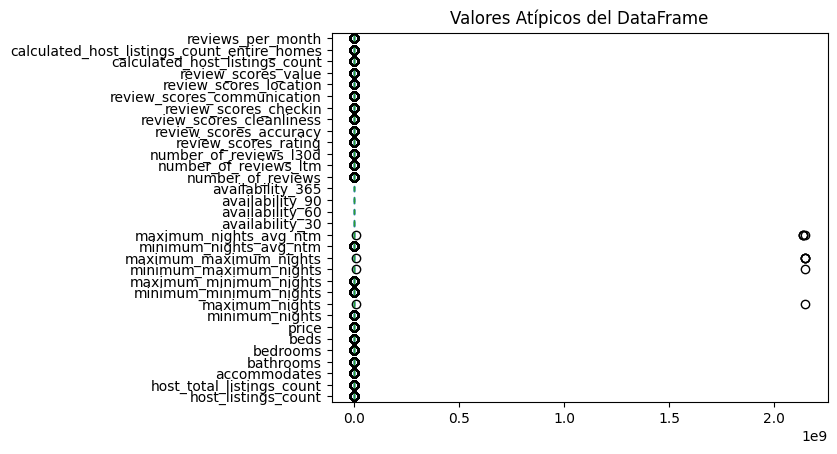

In [75]:
#Para identificar los outlayers

#Realizamos diagrama de caja o bigote de cada columna del dataframe
fig = plt.figure(figsize=(20, 15))
cuantitativas.plot(kind='box', vert=False)
plt.title("Valores Atípicos del DataFrame")
plt.show()   # dibujamos el diagrama

In [76]:
#Método aplicando Cuartiles. Encuentro cuartiles 0.25 y 0.75
y=cuantitativas
percentile25=y.quantile(0.25) #Q1
percentile75=y.quantile(0.75) #Q3
iqr=percentile75-percentile25

Limite_Superior_iqr = percentile75 + 1.5*iqr
Limite_Inferior_iqr = percentile25 - 1.5*iqr
print("Limite Superior permitido", Limite_Superior_iqr)
print("Limite Inferior permitido", Limite_Inferior_iqr)

Limite Superior permitido host_listings_count                               6.000
host_total_listings_count                        11.000
accommodates                                      7.000
bathrooms                                         1.000
bedrooms                                          3.500
beds                                              3.500
price                                           485.500
minimum_nights                                    9.500
maximum_nights                                 2745.000
minimum_minimum_nights                           11.000
maximum_minimum_nights                           12.000
minimum_maximum_nights                         2752.500
maximum_maximum_nights                         2718.000
minimum_nights_avg_ntm                            9.500
maximum_nights_avg_ntm                         2722.500
availability_30                                  32.500
availability_60                                  90.000
availability_90       

In [77]:
#Obtenemos datos y los outliners se convierten en nulos en el dataframe
Cuantitativas1=cuantitativas[(y<=Limite_Superior_iqr)&(y>=Limite_Inferior_iqr)]
Cuantitativas1

,host_listings_count,host_total_listings_count,accommodates,bathrooms,bedrooms,beds,price,minimum_nights,maximum_nights,minimum_minimum_nights,...,review_scores_rating,review_scores_accuracy,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,calculated_host_listings_count,calculated_host_listings_count_entire_homes,reviews_per_month
0,1.0,1.0,2.0,1.0,1.0,1.0,113.0,2.0,30.0,2.0,...,5.00,5.00,5.00,5.00,5.00,5.00,5.00,1.0,1.0,0.05
1,2.0,4.0,2.0,1.0,0.0,1.0,95.0,2.0,730.0,2.0,...,4.61,4.64,4.59,4.81,4.84,4.96,4.59,1.0,1.0,2.23
2,1.0,10.0,4.0,1.0,2.0,1.0,145.0,NaN,130.0,2.0,...,4.73,4.81,4.45,4.92,4.89,4.93,4.74,1.0,1.0,2.20
3,1.0,1.0,3.0,NaN,2.0,NaN,NaN,7.0,365.0,7.0,...,4.80,5.00,5.00,5.00,5.00,5.00,5.00,1.0,1.0,0.03
4,1.0,2.0,6.0,1.0,3.0,0.0,450.0,5.0,120.0,5.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,1.0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95456,2.0,3.0,4.0,1.0,1.0,2.0,77.0,1.0,365.0,1.0,...,5.00,5.00,5.00,5.00,5.00,5.00,5.00,2.0,2.0,1.00
95457,NaN,7.0,6.0,NaN,3.0,3.0,NaN,2.0,365.0,2.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
95458,NaN,NaN,1.0,1.0,NaN,1.0,38.0,1.0,365.0,1.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN
95459,NaN,NaN,1.0,1.0,NaN,2.0,43.0,NaN,1125.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [78]:
# Identificar valores nulos por columna después de eliminar outliers
valores_nulos_outliers = Cuantitativas1.isnull().sum()
valores_nulos_outliers

host_listings_count                            19366
host_total_listings_count                      17642
accommodates                                    2433
bathrooms                                      44589
bedrooms                                        9420
beds                                           36405
price                                          37001
minimum_nights                                 18379
maximum_nights                                     2
minimum_minimum_nights                         17621
maximum_minimum_nights                         18710
minimum_maximum_nights                             2
maximum_maximum_nights                             5
minimum_nights_avg_ntm                         18976
maximum_nights_avg_ntm                             5
availability_30                                    0
availability_60                                    0
availability_90                                    0
availability_365                              

In [79]:
#Reemplazamos valores atípicos (nulos) del df con "mean"
#Realizamos copia del df
Cuantitativas_limpio=Cuantitativas1.copy()
Cuantitativas_limpio=Cuantitativas_limpio.fillna(round(Cuantitativas1.mean(),1))
Cuantitativas_limpio

,host_listings_count,host_total_listings_count,accommodates,bathrooms,bedrooms,beds,price,minimum_nights,maximum_nights,minimum_minimum_nights,...,review_scores_rating,review_scores_accuracy,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,calculated_host_listings_count,calculated_host_listings_count_entire_homes,reviews_per_month
0,1.0,1.0,2.0,1.0,1.0,1.0,113.0,2.0,30.0,2.0,...,5.00,5.00,5.00,5.00,5.00,5.00,5.00,1.0,1.0,0.05
1,2.0,4.0,2.0,1.0,0.0,1.0,95.0,2.0,730.0,2.0,...,4.61,4.64,4.59,4.81,4.84,4.96,4.59,1.0,1.0,2.23
2,1.0,10.0,4.0,1.0,2.0,1.0,145.0,2.6,130.0,2.0,...,4.73,4.81,4.45,4.92,4.89,4.93,4.74,1.0,1.0,2.20
3,1.0,1.0,3.0,1.0,2.0,1.5,171.9,7.0,365.0,7.0,...,4.80,5.00,5.00,5.00,5.00,5.00,5.00,1.0,1.0,0.03
4,1.0,2.0,6.0,1.0,3.0,0.0,450.0,5.0,120.0,5.0,...,4.80,4.80,4.70,4.90,4.90,4.90,4.70,1.0,1.0,0.80
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95456,2.0,3.0,4.0,1.0,1.0,2.0,77.0,1.0,365.0,1.0,...,5.00,5.00,5.00,5.00,5.00,5.00,5.00,2.0,2.0,1.00
95457,1.4,7.0,6.0,1.0,3.0,3.0,171.9,2.0,365.0,2.0,...,4.80,4.80,4.70,4.90,4.90,4.90,4.70,1.2,1.0,0.80
95458,1.4,2.0,1.0,1.0,1.3,1.0,38.0,1.0,365.0,1.0,...,4.80,4.80,4.70,4.90,4.90,4.90,4.70,1.2,0.0,0.80
95459,1.4,2.0,1.0,1.0,1.3,2.0,43.0,2.6,1125.0,2.5,...,4.80,4.80,4.70,4.90,4.90,4.90,4.70,1.2,1.0,0.80


In [80]:
# Corroborar valores nulos finales después del tratamiento de outliers
valores_nulos_final = Cuantitativas_limpio.isnull().sum()
valores_nulos_final

host_listings_count                            0
host_total_listings_count                      0
accommodates                                   0
bathrooms                                      0
bedrooms                                       0
beds                                           0
price                                          0
minimum_nights                                 0
maximum_nights                                 0
minimum_minimum_nights                         0
maximum_minimum_nights                         0
minimum_maximum_nights                         0
maximum_maximum_nights                         0
minimum_nights_avg_ntm                         0
maximum_nights_avg_ntm                         0
availability_30                                0
availability_60                                0
availability_90                                0
availability_365                               0
number_of_reviews                              0
number_of_reviews_lt

In [81]:
#Obtenemos datos limpios del DataFrame
data2_iqr = Cuantitativas_limpio[(y<=Limite_Superior_iqr)&(y>=Limite_Inferior_iqr)]
data2_iqr

,host_listings_count,host_total_listings_count,accommodates,bathrooms,bedrooms,beds,price,minimum_nights,maximum_nights,minimum_minimum_nights,...,review_scores_rating,review_scores_accuracy,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,calculated_host_listings_count,calculated_host_listings_count_entire_homes,reviews_per_month
0,1.0,1.0,2.0,1.0,1.0,1.0,113.0,2.0,30.0,2.0,...,5.00,5.00,5.00,5.00,5.00,5.00,5.00,1.0,1.0,0.05
1,2.0,4.0,2.0,1.0,0.0,1.0,95.0,2.0,730.0,2.0,...,4.61,4.64,4.59,4.81,4.84,4.96,4.59,1.0,1.0,2.23
2,1.0,10.0,4.0,1.0,2.0,1.0,145.0,NaN,130.0,2.0,...,4.73,4.81,4.45,4.92,4.89,4.93,4.74,1.0,1.0,2.20
3,1.0,1.0,3.0,NaN,2.0,NaN,NaN,7.0,365.0,7.0,...,4.80,5.00,5.00,5.00,5.00,5.00,5.00,1.0,1.0,0.03
4,1.0,2.0,6.0,1.0,3.0,0.0,450.0,5.0,120.0,5.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,1.0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95456,2.0,3.0,4.0,1.0,1.0,2.0,77.0,1.0,365.0,1.0,...,5.00,5.00,5.00,5.00,5.00,5.00,5.00,2.0,2.0,1.00
95457,NaN,7.0,6.0,NaN,3.0,3.0,NaN,2.0,365.0,2.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
95458,NaN,NaN,1.0,1.0,NaN,1.0,38.0,1.0,365.0,1.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN
95459,NaN,NaN,1.0,1.0,NaN,2.0,43.0,NaN,1125.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [82]:
#Corroboramos valores nulos del dataframe LIMPIO
valores_nulos=data2_iqr.isnull().sum()
valores_nulos

host_listings_count                            19366
host_total_listings_count                      17642
accommodates                                    2433
bathrooms                                      44589
bedrooms                                        9420
beds                                           36405
price                                          37001
minimum_nights                                 18379
maximum_nights                                     2
minimum_minimum_nights                         17621
maximum_minimum_nights                         18710
minimum_maximum_nights                             2
maximum_maximum_nights                             5
minimum_nights_avg_ntm                         18976
maximum_nights_avg_ntm                             5
availability_30                                    0
availability_60                                    0
availability_90                                    0
availability_365                              

In [83]:
#Reemplazamos valores atípicos (nulos) del dataframe con "mean"
#Realizamos una copia del dataframe
data2_iqr=data2_iqr.copy()
data2_iqr=data2_iqr.fillna(round(data2_iqr.mean(),1))
data2_iqr

,host_listings_count,host_total_listings_count,accommodates,bathrooms,bedrooms,beds,price,minimum_nights,maximum_nights,minimum_minimum_nights,...,review_scores_rating,review_scores_accuracy,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,calculated_host_listings_count,calculated_host_listings_count_entire_homes,reviews_per_month
0,1.0,1.0,2.0,1.0,1.0,1.0,113.0,2.0,30.0,2.0,...,5.00,5.00,5.00,5.00,5.00,5.00,5.00,1.0,1.0,0.05
1,2.0,4.0,2.0,1.0,0.0,1.0,95.0,2.0,730.0,2.0,...,4.61,4.64,4.59,4.81,4.84,4.96,4.59,1.0,1.0,2.23
2,1.0,10.0,4.0,1.0,2.0,1.0,145.0,2.6,130.0,2.0,...,4.73,4.81,4.45,4.92,4.89,4.93,4.74,1.0,1.0,2.20
3,1.0,1.0,3.0,1.0,2.0,1.5,171.9,7.0,365.0,7.0,...,4.80,5.00,5.00,5.00,5.00,5.00,5.00,1.0,1.0,0.03
4,1.0,2.0,6.0,1.0,3.0,0.0,450.0,5.0,120.0,5.0,...,4.80,4.80,4.70,4.90,4.90,4.90,4.70,1.0,1.0,0.80
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95456,2.0,3.0,4.0,1.0,1.0,2.0,77.0,1.0,365.0,1.0,...,5.00,5.00,5.00,5.00,5.00,5.00,5.00,2.0,2.0,1.00
95457,1.4,7.0,6.0,1.0,3.0,3.0,171.9,2.0,365.0,2.0,...,4.80,4.80,4.70,4.90,4.90,4.90,4.70,1.2,1.0,0.80
95458,1.4,2.0,1.0,1.0,1.3,1.0,38.0,1.0,365.0,1.0,...,4.80,4.80,4.70,4.90,4.90,4.90,4.70,1.2,0.0,0.80
95459,1.4,2.0,1.0,1.0,1.3,2.0,43.0,2.6,1125.0,2.5,...,4.80,4.80,4.70,4.90,4.90,4.90,4.70,1.2,1.0,0.80


In [84]:
#Unimos  'cualitativas' y 'unicos' con el dataframe

Datos_limpios = pd.concat([unicos, cualitativas,data2_iqr], axis=1)
Datos_limpios

,id,scrape_id,host_id,latitude,longitude,listing_url,last_scraped,source,name,description,...,review_scores_rating,review_scores_accuracy,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,calculated_host_listings_count,calculated_host_listings_count_entire_homes,reviews_per_month
0,3109,20240906025355,3631,48.831910,2.318700,https://www.airbnb.com/rooms/3109,2024-09-11,city scrape,zen and calm,Lovely Appartment with one bedroom with a Quee...,...,5.00,5.00,5.00,5.00,5.00,5.00,5.00,1.0,1.0,0.05
1,5396,20240906025355,7903,48.852470,2.358350,https://www.airbnb.com/rooms/5396,2024-09-13,city scrape,Your perfect Paris studio on Île Saint-Louis,"NEW SOFA-BED SINCE JUNE 2023, Please disregard...",...,4.61,4.64,4.59,4.81,4.84,4.96,4.59,1.0,1.0,2.23
2,7397,20240906025355,2626,48.859090,2.353150,https://www.airbnb.com/rooms/7397,2024-09-06,city scrape,MARAIS - 2ROOMS APT - 2/4 PEOPLE,"VERY CONVENIENT, WITH THE BEST LOCATION !",...,4.73,4.81,4.45,4.92,4.89,4.93,4.74,1.0,1.0,2.20
3,7964,20240906025355,22155,48.874170,2.342450,https://www.airbnb.com/rooms/7964,2024-09-10,previous scrape,Sunny apartment with balcony,"We are renting our a spacious, sunny fully fur...",...,4.80,5.00,5.00,5.00,5.00,5.00,5.00,1.0,1.0,0.03
4,241715,20240906025355,3342097,48.893464,2.378341,https://www.airbnb.com/rooms/241715,2024-09-11,city scrape,Big Cosy Appartement with 100 m2 Terrace in Paris,Come to stay in our unique Parisian flat to en...,...,4.80,4.80,4.70,4.90,4.90,4.90,4.70,1.0,1.0,0.80
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
95456,1238568635341928457,20240906025355,539077658,48.838180,2.257970,https://www.airbnb.com/rooms/1238568635341928457,2024-09-13,city scrape,"Spacieux studio 4P, porte st cloud",Forget your worries at this spacious (42m2) an...,...,5.00,5.00,5.00,5.00,5.00,5.00,5.00,2.0,2.0,1.00
95457,1238594326004996232,20240906025355,492686946,48.875698,2.289969,https://www.airbnb.com/rooms/1238594326004996232,2024-09-11,city scrape,Luxury 3BR Arc Triomphe Champs Élysée,Spacious 3 Bedroom Apartment - Close to Champs...,...,4.80,4.80,4.70,4.90,4.90,4.90,4.70,1.2,1.0,0.80
95458,1238755949783144791,20240906025355,264290202,48.865738,2.357416,https://www.airbnb.com/rooms/1238755949783144791,2024-09-07,city scrape,[F-16] 파리 5인여성 다인실방,Centrally located with the best accessibility.,...,4.80,4.80,4.70,4.90,4.90,4.90,4.70,1.2,0.0,0.80
95459,1239120896239244086,20240906025355,169497320,48.892113,2.360589,https://www.airbnb.com/rooms/1239120896239244086,2024-09-13,city scrape,Large and bright flat nearby Montmartre - Paris,MIDTERM STAY ONLY - Located close to the mythi...,...,4.80,4.80,4.70,4.90,4.90,4.90,4.70,1.2,1.0,0.80


In [85]:
#Corroboramos valores nulos del dataframe LIMPIO
valores_nulos_final=Datos_limpios.isnull().sum()
valores_nulos_final

id                                             0
scrape_id                                      0
host_id                                        0
latitude                                       0
longitude                                      0
                                              ..
review_scores_location                         0
review_scores_value                            0
calculated_host_listings_count                 0
calculated_host_listings_count_entire_homes    0
reviews_per_month                              0
Length: 71, dtype: int64

In [86]:
#Convertir DataFrame a CSV
Datos_limpios.to_csv("Base_Paris_LIMPIA.csv")